# Séance 1 : Fondations Computationnelles — Python pour Mathématiciens

**Objectifs** :
- Prendre en main Python pour l'implémentation d'algorithmes mathématiques.
- Implémenter l'algorithme d'Euclide étendu et le crible d'Ératosthène.
- Mesurer et analyser la complexité algorithmique.

---

## 1. Préparation de l'environnement

Exécutez la cellule suivante pour importer les bibliothèques nécessaires.

In [1]:
import timeit
import matplotlib.pyplot as plt
import math
%matplotlib inline

## 2. Algorithme d'Euclide étendu

### Version récursive

Rappel : l'algorithme retourne $(d, u, v)$ tel que $d = a u + b v = \mathrm{pgcd}(a,b)$.

In [2]:
def euclide_etendu_rec(a, b):
    """
    Algorithme d'Euclide étendu (version récursive).
    Retourne (pgcd, u, v) avec a*u + b*v = pgcd.
    """
    if b == 0:
        return (a, 1, 0)
    else:
        d, u1, v1 = euclide_etendu_rec(b, a % b)
        u = v1
        v = u1 - (a // b) * v1
        return (d, u, v)

In [3]:
# Test rapide
a, b = 240, 46
d, u, v = euclide_etendu_rec(a, b)
print(f"pgcd({a}, {b}) = {d}")
print(f"{a}*{u} + {b}*{v} = {a*u + b*v}")

pgcd(240, 46) = 2
240*-9 + 46*47 = 2


### Version itérative (à compléter)

**Exercice** : Implémentez ci-dessous une version itérative de l'algorithme d'Euclide étendu. Vous pouvez utiliser une boucle `while` et mettre à jour les coefficients.

In [4]:
def euclide_etendu_iter (p , q ) :    
    a = max(p, q)
    b = min(p, q)
    if b == 0:
        return (a, a, 0)
    else:
        # L1 représente les coefficients de Bézout de a (resp L2 pour b)
        L1 = [1, 0]
        L2 = [0, 1]

        while b!=0:
            q = a // b
            r = a % b

            # copie la liste L2, si on change  L2, L change egalement une fois la boucle revient à l' instruction
            L = L2[:] 

            # mise à jour des coefficients et insertion du nouveau liste 
            for i in range(2):
                L2[i] = L1[i] - q * L2[i]
            L1 = L

            #print(f" a : {a} , L1,L2 : {L1,L2}") Verification du calcul
        
            a = b
            b = r

        # assigner u et v
        u = L1[0]
        v = L1[1]
        return a, u, v

In [5]:
# Test de votre version itérative
d, u, v = euclide_etendu_iter(240, 46)
assert d == 2 and 240*u + 46*v == 2
print("Test réussi !")

Test réussi !


## 3. Crible d'Ératosthène

### Version de base

In [6]:
def eratosthene(n):
    """
    Retourne la liste des nombres premiers <= n.
    """
    if n < 2:
        return []
    est_premier = [True] * (n+1)
    est_premier[0] = est_premier[1] = False
    for p in range(2, int(n**0.5) + 1):
        if est_premier[p]:
            for multiple in range(p*p, n+1, p):
                est_premier[multiple] = False
    return [i for i, prime in enumerate(est_premier) if prime]

In [7]:
# Test
print(eratosthene(30))

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29]


### Version optimisée (nombres impairs uniquement)

**Exercice** : Modifiez le crible pour ne traiter que les nombres impairs (sauf 2).

In [8]:
def eratosthene_opt(n):
    """
    Crible optimisé pour ne parcourir que les impairs.
    """
    # Votre code ici
    if n < 2:
        return []
    est_premier = [True] * (n+1)
    est_premier[0] = est_premier[1] = False

    # on élimine tous les pairs > 2
    for i in range(4, n + 1, 2):
        est_premier[i] = False

    for p in range(3, int(n**0.5) + 1,2): # calcul des impairs seulement         
        if est_premier[p]:
            #p --> 2*p pour parcourir seulement les impairs au lieu de recalculer les pairs
            for multiple in range(p*p, n+1, 2*p):
                est_premier[multiple] = False
    return [i for i, prime in enumerate(est_premier) if prime]
print(eratosthene_opt(30))

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29]


## 4. Analyse de complexité empirique

Nous allons mesurer le temps d'exécution du crible pour différentes valeurs de $n$.

In [9]:
def mesurer_temps(fonction, n, repetitions=5):
    """
    Mesure le temps moyen d'exécution de fonction(n) sur 'repetitions' exécutions.
    """
    timer = timeit.Timer(lambda: fonction(n))
    temps = timer.timeit(number=repetitions)
    return temps / repetitions

In [10]:
valeurs_n = [10**i for i in range(3, 8)]  # 10^3 à 10^7
temps_base = []
temps_opt = []

for n in valeurs_n:
    t_base = mesurer_temps(eratosthene, n, repetitions=3)
    t_opt = mesurer_temps(eratosthene_opt, n, repetitions=3)  # décommentez quand votre fonction est prête
    temps_base.append(t_base)
    temps_opt.append(t_opt)
    print(f"n = {n:7d} : temps base = {t_base:.4f} s")
    print(f"n = {n:7d} : temps base = {t_opt:.4f} s")

n =    1000 : temps base = 0.0001 s
n =    1000 : temps base = 0.0001 s
n =   10000 : temps base = 0.0010 s
n =   10000 : temps base = 0.0010 s
n =  100000 : temps base = 0.0143 s
n =  100000 : temps base = 0.0092 s
n = 1000000 : temps base = 0.1257 s
n = 1000000 : temps base = 0.0921 s
n = 10000000 : temps base = 1.4909 s
n = 10000000 : temps base = 1.0787 s


### Visualisation

On souhaite vérifier que le temps est proportionnel à $n \log \log n$.

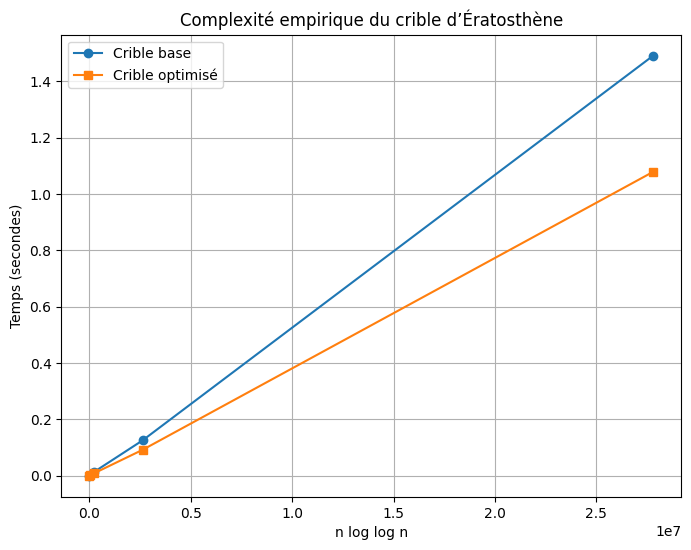

In [ ]:
n_loglog = [n * math.log(math.log(n)) if n>2 else 0 for n in valeurs_n]

plt.figure(figsize=(8,6))
plt.plot(n_loglog, temps_base, 'o-', label='Crible base')
plt.plot(n_loglog, temps_opt, 's-', label='Crible optimisé')  # à décommenter
plt.xlabel('n log log n')
plt.ylabel('Temps (secondes)')
plt.title('Complexité empirique du crible d’Ératosthène')
plt.legend()
plt.grid(True)
plt.show()

**Question** : Le graphique est-il approximativement une droite ? Que peut-on en conclure ?

# Reponses:
==> Le graphique est approximativement une droite, on peut dire que la version de base tend rapidement vers l'infini que la version de opt.Donc la version opt est bien meilleur

## 5. Conclusion et rendu

- Assurez-vous que votre notebook contient **toutes** les fonctions demandées (versions récursive et itérative d'Euclide étendu, crible optimisé).
- Ajoutez des commentaires expliquant vos choix d'implémentation.
- Exportez ce notebook au format `.ipynb` et commitez-le dans votre dépôt GitHub.

**Rappel** : Vous pouvez utiliser l'IA comme assistant, mais vous devez comprendre chaque ligne de code et être capable de l'expliquer.